## IMPORTING LIBRARIES AND LOADING DATA

In [1]:
#!pip install mplsoccer hyperopt shap xgboost lightgbm imbalanced-learn

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%reload_ext autoreload

In [4]:
# System imports

from pathlib import Path
import sys
import os
import pandas as pd
import numpy as np
from scipy import stats

# Define project directory for notebook
PROJECT_DIR = Path.cwd().parent  # Move to parent directory relative to notebooks
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR / 'src'))

DATA_PATH      = PROJECT_DIR / 'data' / 'shots_combined_2015_2016.csv'
FIFA_2022_PATH = PROJECT_DIR / 'data' / 'shots_fifa_world_cup_2022.csv'

# Imports from custom modules
from src.data_processing import load_data, clean_data, select_features, prepare_test_set
from src.feature_engineering import (transform_to_binary, analyze_categorical_variables, 
                              extract_xy, calculate_angles_distances, transform_body_part, 
                              analyze_freeze_frame, standardize_features, create_dummies,
                              transform_play_pattern)
from src.models import prepare_train_calibration_split, train_logistic_regression, train_random_forest, train_xgboost
from src.evaluation import evaluate_model, calibrate_best_model
from src.visualization import (create_quantile_efficiency, plot_shot_accuracy_by_distance_and_y, 
                        visualize_shot_situation, plot_binary_features_comparison, 
                        plot_stacked_bar, plot_body_part_by_distance_quantile, 
                        plot_shot_success_heatmap, plot_shot_effectiveness_by_quantiles,
                        plot_angle_distribution, plot_xg_scatter,
                        plot_passes_in_sequence_effectiveness,
                        plot_goalkeeper_distance_ratio_distribution,
                        plot_xg_shap_summary)

In [5]:
df = load_data(DATA_PATH)

Data loaded: (45719, 121)


The loaded dataset is highly extensive. It contains **45,719 observations** and **121 variables**. However, not all variables are related to shots. Therefore, I can now remove variables that have NaN values for all observations.

In [6]:
df_cleaned = clean_data(df)

Removed 80 columns with all NaN
New data dimensions: (45719, 41)
Remaining 41 columns:
- duration
- id
- index
- location
- match_id
- minute
- n_passes_in_sequence
- off_camera
- out
- period
- play_pattern
- player
- player_id
- position
- possession
- possession_team
- possession_team_id
- related_events
- second
- shot_aerial_won
- shot_body_part
- shot_deflected
- shot_end_location
- shot_first_time
- shot_follows_dribble
- shot_freeze_frame
- shot_key_pass_id
- shot_one_on_one
- shot_open_goal
- shot_outcome
- shot_redirect
- shot_saved_off_target
- shot_saved_to_post
- shot_statsbomb_xg
- shot_technique
- shot_type
- team
- team_id
- timestamp
- type
- under_pressure


As a result of this operation, the dataset size decreased to **40 columns**. After reviewing the remaining variables, I was able to select those potentially relevant for the future model.

## INITIAL DATASET WITHOUT VARIABLE PROCESSING

In [7]:
features = [
    'shot_outcome', # target variable
    'under_pressure', 'location', 
    'shot_technique', 'shot_body_part',
    'shot_type', 'shot_first_time', 'shot_open_goal',
    'shot_one_on_one', 'shot_follows_dribble', 'shot_freeze_frame',
    'player_id', # for shot_body_part transformation
    'n_passes_in_sequence',
    'play_pattern',
]

df_shots = select_features(df_cleaned, features)

Selected 14 features
New data dimensions: (45719, 14)


For further processing, I selected the following variables:
- **shot_outcome** - target variable describing the result of the shot taken,
- **under_pressure** - binary variable: whether the shot was taken under opponent pressure,
- **location** - informational variable about shot location: coordinates x (0-120) and y (0-80),
- **shot_technique** - categorical variable,
- **shot_body_part** - categorical variable: body part used for the shot,
- **shot_type** - categorical variable: shot situation: 'open play', free kick, penalty, etc.,
- **shot_first_time** - binary variable: whether shot was taken first-time (without control),
- **shot_open_goal** - binary variable: whether shot was taken at 'open goal',
- **shot_one_to_one** - binary variable: whether shot was taken in 'one-on-one' situation,
- **shot_follows_dribble** - binary variable: whether shot was taken after dribbling,
- **shot_freeze_frame** - variable containing locations of other players at moment of shot,
- **play_pattern** - categorical variable: how the possession leading to the shot developed (open play, corner, free kick, counter-attack, etc.),
- **n_passes_in_sequence** - ordinal variable: number of passes in the possession sequence leading up to the shot,
- **player_id** - helper variable: player identification number.

## TRANSFORMING TARGET VARIABLE TO BINARY VARIABLE

The first step after defining the dataset was creating the target variable by transforming shot_outcome into a binary variable.

In [8]:
df_shots = transform_to_binary(df_shots, column='shot_outcome', positive_value='Goal')

Original distribution of shot_outcome:
shot_outcome
Off T               33.00
Blocked             24.70
Saved               23.50
Goal                10.29
Wayward              5.91
Post                 1.90
Saved Off Target     0.35
Saved to Post        0.33
Name: proportion, dtype: float64

Distribution of shot_outcome after transformation:
shot_outcome
0    89.71
1    10.29
Name: proportion, dtype: float64


Originally, the variable contained many categories. For me, however, only the distinction was important: **goal vs no goal**. Therefore, I assigned 1 to observations labeled "Goal" and 0 to the rest. As it turned out, only about **10% of all shots resulted in scoring a goal**. This aligns with a commonly observed phenomenon in football, where on average every 10th offensive action ends with a shot, and every 10th shot ends with a goal. As a result, barely 1% of offensive actions culminate in scoring a goal.

##  INITIAL TRANSFORMATIONS AND DATA CLEANING

In [9]:
print(df_shots.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45719 entries, 0 to 45718
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   shot_outcome          45719 non-null  int32  
 1   under_pressure        12290 non-null  object 
 2   location              45719 non-null  object 
 3   shot_technique        45719 non-null  object 
 4   shot_body_part        45719 non-null  object 
 5   shot_type             45719 non-null  object 
 6   shot_first_time       14402 non-null  object 
 7   shot_open_goal        484 non-null    object 
 8   shot_one_on_one       2332 non-null   object 
 9   shot_follows_dribble  35 non-null     object 
 10  shot_freeze_frame     45285 non-null  object 
 11  player_id             45719 non-null  float64
 12  n_passes_in_sequence  45719 non-null  int64  
 13  play_pattern          45719 non-null  object 
dtypes: float64(1), int32(1), int64(1), object(11)
memory usage: 4.7+ MB
No

All variables considered as explanatory variables for the model are of "object" type. Therefore, transformations will need to be performed on them in the later preparation phase. Additionally, 5 variables have null values. However, according to documentation, these are not true missings: for variables *shot_first_time*, *shot_open_goal*, *shot_one_on_one*, *shot_follows_dribble* Null value is equivalent to False. For the *shot_freeze_frame variable*, it takes NaN values for penalties (it doesn't make sense to provide player positioning then). This assumption can be quickly confirmed:

In [10]:
df_shots['shot_type'][df_shots['shot_freeze_frame'].isna()].unique()

array(['Penalty'], dtype=object)

Indeed, NaN values in the *shot_freeze_frame* column occur only for penalties. The next step is to take a closer look at variables that are assumed to have categories.

In [11]:
categorical = [
    'under_pressure', 'shot_technique', 'shot_body_part',
    'shot_type', 'shot_first_time', 'shot_open_goal',
    'shot_one_on_one', 'shot_follows_dribble', 'play_pattern'
]

distribution = analyze_categorical_variables(df_shots, categorical)

Distribution for variable 'under_pressure':
under_pressure
NaN     73.12
True    26.88
Name: proportion, dtype: float64
--------------------------------------------------
Distribution for variable 'shot_technique':
shot_technique
Normal           75.87
Half Volley      14.99
Volley            6.90
Lob               0.88
Overhead Kick     0.57
Backheel          0.40
Diving Header     0.38
Name: proportion, dtype: float64
--------------------------------------------------
Distribution for variable 'shot_body_part':
shot_body_part
Right Foot    52.14
Left Foot     31.17
Head          16.45
Other          0.24
Name: proportion, dtype: float64
--------------------------------------------------
Distribution for variable 'shot_type':
shot_type
Open Play    94.26
Free Kick     4.65
Penalty       1.06
Corner        0.03
Name: proportion, dtype: float64
--------------------------------------------------
Distribution for variable 'shot_first_time':
shot_first_time
NaN     68.5
True    31.5
Name: 

- **under_pressure** - 27% of shots were taken under opponent pressure and 73% without. Both categories are sufficiently numerous, so I'm keeping the variable. It will be converted to a binary variable.

- **shot_technique** - many categories with the most numerous being "Normal" (76% of shots). I decided to transform the variable into a binary variable: normal_shot. For "Normal" category I'll assign value 1, and for others value 0 (volleys, acrobatic shots, etc.)

- **shot_body_part** - three relatively numerous categories (Right Foot, Left Foot, Head) and one (Other) representing only 2.5%. I'll keep the first three categories, but instead of raw Left/Right Foot data, this should also relate to dribbling or foot dominance prediction. I'll group the least numerous categories as "other"

- **shot_type** - contains 4 categories, with one strongly dominant (Open Play - 94%). I will use this variable to create the **open_play_shot** binary feature. Penalties will be removed entirely (see next step), as their nature would distort model results.

- **shot_first_time** - 31.5% of shots were taken first-time and 68.5% with control (or from standing ball). Categories of this variable are well balanced. Variable will be converted to binary variable.

- **shot_open_goal**, **shot_one_on_one**, **shot_follows_dribble** - strongly imbalanced variables: **shot_one_on_one** variable contains 5% True values, but due to information I'll be able to extract from **shot_freeze_frame** variable, I decided that like the other two variables, this one will also be removed from the dataset.

- **play_pattern** - describes the type of possession leading to the shot. I will group it into four categories: **corner**, **set_piece** (free kicks), **counter** (counter-attacks), and **open_play** (reference category, including the rare "Other" patterns). These will be encoded as dummy variables.

- **n_passes_in_sequence** - counts the number of passes in the possession sequence before the shot. This variable captures the build-up complexity: quick attacks (few passes) vs. patient possession (many passes). It will be log-transformed (log1p) to reduce right skewness and then standardized.

In [12]:
print("All shots: ")
result1 = analyze_categorical_variables(df_shots, ['shot_outcome'])
print("Penalties")
result2 = analyze_categorical_variables(df_shots[df_shots['shot_type']=='Penalty'], ['shot_outcome'])

All shots: 
Distribution for variable 'shot_outcome':
shot_outcome
0    89.71
1    10.29
Name: proportion, dtype: float64
--------------------------------------------------
Penalties
Distribution for variable 'shot_outcome':
shot_outcome
1    75.72
0    24.28
Name: proportion, dtype: float64
--------------------------------------------------


As I noted in the previous step, penalties, despite representing only 1% of shots, end in goals 75% of the time. Additionally, their nature (taken from the same point, no opponent positioning, etc.) means they could strongly distort model results (e.g., artificially inflating shot effectiveness from around the "11-meter" area). Therefore, I decided to remove observations labeled as *Penalty*.

In [13]:
df_shots = df_shots[df_shots['shot_type']!='Penalty']
result = analyze_categorical_variables(df_shots, ['shot_outcome'])

Distribution for variable 'shot_outcome':
shot_outcome
0    90.41
1     9.59
Name: proportion, dtype: float64
--------------------------------------------------


After this operation, there was a slight decrease in the share of goals, which currently represent about **9.6% of all shots**.

### Continuous Variables

#### Coordinates - distance and shot angle

Coordinates of the point from which the shot was taken are encoded in the **location** variable in format [x, y]. The pitch has dimensions **120x80** (important not to treat this as meters or yards, as pitches have different dimensions and this is just a standardized pitch size proposed by StatsBomb) and the direction of attack runs from x=0 to x=120 (opponent's goal). Therefore, to calculate the distance from goal, or rather from the end line, the shot was taken from, a transformation to *distance_to_end_line* (120-x) will need to be performed.

In [14]:
df_shots = extract_xy(df_shots)
print(df_shots[['x', 'y', 'distance_to_end_line']].head())

       x     y  distance_to_end_line
0  112.0  35.7                   8.0
1   96.1  19.5                  23.9
2  110.3  41.2                   9.7
4  110.5  23.4                   9.5
5  104.7  56.0                  15.3


Visualizing shots based on coordinates is problematic because sectors on the pitch are unequal in number, and even strongly imbalanced. There must be more shots from close and central positions than those from distant and more lateral areas. Additionally, the data may contain outliers, e.g., when bold shots from 40-50 meters appear or attempts to place the ball in the net when striking from near the sidelines of the pitch. To mitigate these problems, I decided to divide shots into equal-sized quantiles.

Chart saved to ../assets/eda/shot_accuracy_by_distance_and_y.png


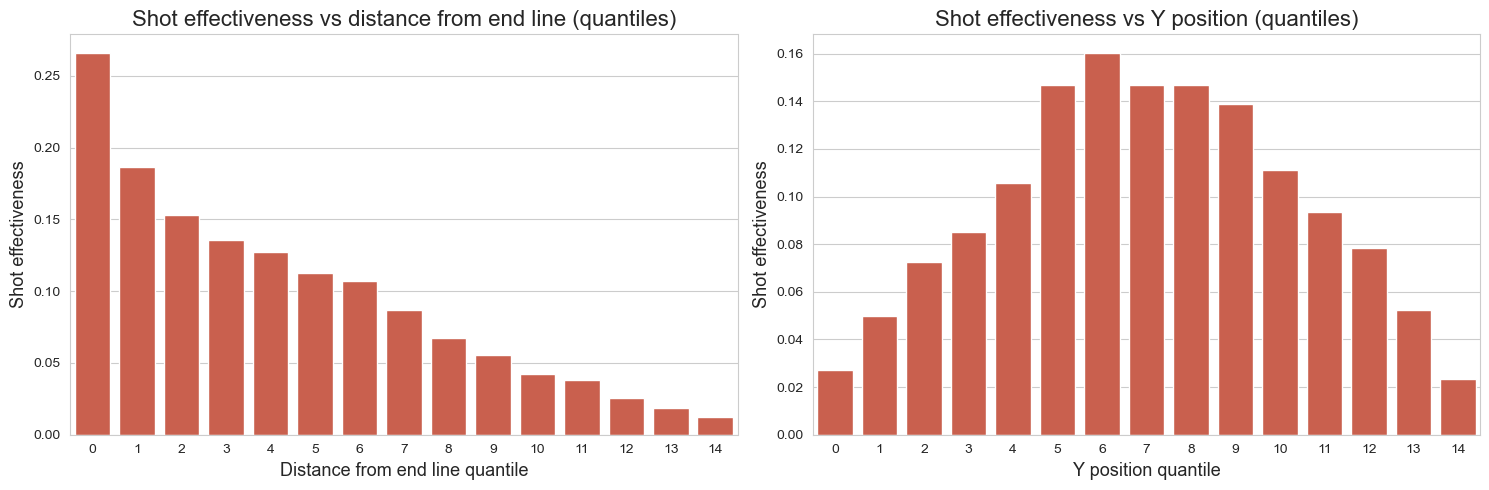

In [15]:
# Przygotowanie danych
eff_by_distance = create_quantile_efficiency(df_shots, 'distance_to_end_line', 'shot_outcome')
eff_by_y = create_quantile_efficiency(df_shots, 'y', 'shot_outcome')

fig, ax = plot_shot_accuracy_by_distance_and_y(eff_by_distance, eff_by_y, save_path='../assets/eda/shot_accuracy_by_distance_and_y.png')

Thanks to using quantiles we clearly see that shot effectiveness decreases with increasing distance from the end line. For the first quantile it's over 26%, for the seventh around 9%, and for the last about 1%. A clear pattern is also visible for the effectiveness chart relative to pitch width (y coordinate). Shots taken from central positions (quantile 6) are characterized by 16% effectiveness, while those from side positions are below 5%.

Coordinates x (or rather 120-x) and y seem to be good differentiating variables. However, two more intuitive measures can be defined:
- **distance** - distance from the point where shot was taken (x,y) to goal center (120,40)
- **angle** - angle formed between lines connecting shot point (x,y) with goal posts (120,36 and 120,44). This measure describes how "large" the goal appears from the shooter's viewpoint. It will probably be strongly **negatively correlated with distance** variable, as angle will decrease with increasing distance.

In [16]:
df_shots = calculate_angles_distances(df_shots)

In [17]:
df_shots[['distance', 'angle']].describe()

,distance,angle
count,45233.000000,45233.000000
mean,19.520543,24.874447
std,8.713346,15.362327
min,0.632456,0.000000
25%,12.376187,14.859554
50%,19.027612,19.278945
75%,25.927784,30.401229
max,88.833158,180.000000


**Distance** variable takes values from 0.63 (very close shot) to 88.8 (shot from distance greater than pitch width). Average shot distance is about 19.5 units and almost coincides with median of 19 units. For shot **angle**, values are around 24.9 degrees while median is lower at 19.3 degrees.

Looking at descriptive statistics of angle variable, one can hypothesize that it's strongly right-skewed. This is evidenced by: 
- mean higher than median,
- quartile asymmetry, as differences between consecutive values are: 15°, 4.5°, 11° and 150° (!),
- relatively high standard deviation compared to quartile distribution

In the next part, I will take a closer look at the presumed asymmetry of the distribution.

### Categorical Variables

#### Body part - better_foot, worse_foot, head

Raw data contained in the **body_part** variable may have limited predictive power, due to the fact that different players have different dominant feet, and consequently some of them will prefer shots with the right foot, and some with the left. StatsBomb data does not contain information about which foot is preferred or dominant for a player. Therefore, I decided to check for each player which foot they used for more shots and consider that foot as their dominant one. In cases where a player took an equal number of shots with both feet, I decided to classify them as right-footed, as there are significantly more such players than left-footed ones. I assigned the new data to the **refined_body_part** variable.

In [18]:
df_shots = transform_body_part(df_shots)

Distribution of dominant foot among players:
foot_type
dominant_right    67.09
dominant_left     32.91
Name: proportion, dtype: float64
--------------------------------------------------
Distribution of shots by type:
refined_body_part
better_foot    66.22
worse_foot     17.11
head           16.67
Name: proportion, dtype: float64


After conducting the above classification, it turned out that approximately 67% of players in the dataset are right-footed, while 33% are left-footed players. After applying feature engineering and creating **refined_body_part**, I obtained a new percentage distribution of shots: 66% of shots were taken with the better foot, 17% with the worse foot, and also about 17% were headers. In accordance with previous arrangements, I removed observations labeled "Others" as they represented only 0.24% of observations.

#### Transformation to Binary Variables

In accordance with previous assumptions, I transform some variables (**under_pressure**, **shot_first_time**) into binary variables, and create new binary features **normal_shot** (from shot_technique) and **open_play_shot** (from shot_type). I also apply log transformation to **n_passes_in_sequence** to reduce its right skewness.

In [19]:
# Transform variables to binary
df_shots = transform_to_binary(df_shots, 'under_pressure', positive_value=True, display_distribution=False)
df_shots = transform_to_binary(df_shots, 'shot_first_time', positive_value=True, display_distribution=False)

# Create new binary variables based on other columns
# For shot_technique -> normal_shot
# For shot_type -> open_play_shot
df_shots['normal_shot'] = np.where(df_shots['shot_technique'] == 'Normal', 1, 0)
df_shots['open_play_shot'] = np.where(df_shots['shot_type'] == 'Open Play', 1, 0)

# Filter corner kicks (only 0.02% of observations)
df_shots = df_shots[df_shots['shot_type'] != 'Corner']

# Reset index
df_shots = df_shots.reset_index(drop=True)

#### Transforming shot_freeze_frame into defenders_in_path and goalkeeper_in_path

Useful information can be extracted from the **shot_freeze_frame** variable. It contains the coordinates of player locations at the moment the shot was taken. This makes it possible to determine how many defenders were in the goal area and whether the goalkeeper was in the path of the ball. I defined the area "in the goal area" as the triangle formed by the shooting player and the goal posts. If a defender or goalkeeper was in this triangle, I classified them as present on the shot line (since in practice they were blocking part of the goal from the shooter).

In [20]:
df_shots = analyze_freeze_frame(df_shots)

DEFENDERS ON SHOT LINE:
defenders_in_path
0    48.57
1    34.26
2    10.95
3     4.12
4     1.56
5     0.43
6     0.08
7     0.02
8     0.01
Name: proportion, dtype: float64

GOALKEEPER ON SHOT LINE:
goalkeeper_in_path
0     3.94
1    96.06
Name: proportion, dtype: float64

GOALKEEPER DISTANCE RATIO:
count    45108.000000
mean         0.220611
std          0.180724
min          0.004788
25%          0.103772
50%          0.168024
75%          0.264795
max          1.000000
Name: goalkeeper_distance_ratio, dtype: float64


The **defenders_in_path** variable takes values from 0 to 8. However, it's clear that smaller values significantly predominate. In nearly 49% of cases there was no defender in the shot path, in 34% of cases there was one defender, in 11% of actions two defenders, and in 4% of shots there were three defenders. The subsequent values are so few that I decided to **group them together with value 3**.

Meanwhile, the **goalkeeper_in_path** variable is a binary variable that takes value 1 when the goalkeeper was in the shot radius and 0 otherwise. In 96% of shots, the goalkeeper was positioned between the shooter and the goal.

The **goalkeeper_distance_ratio** variable (range: 0-1) measures how far the goalkeeper has advanced from the goal center toward the shooter. With a mean of 0.23, goalkeepers typically come off their line by about 23% of the shot distance to narrow the shooting angle. The distribution shows moderate variation (std = 0.18), with 75% of values below 0.26.

In [21]:
df_shots['defenders_in_path'] = np.where(df_shots['defenders_in_path'] >= 3, 3, df_shots['defenders_in_path'])

In [22]:
df_shots['log_passes_in_sequence'] = np.log1p(df_shots['n_passes_in_sequence'])

print(f"n_passes_in_sequence — skewness: {df_shots['n_passes_in_sequence'].skew():.3f}")
print(f"log_passes_in_sequence — skewness: {df_shots['log_passes_in_sequence'].skew():.3f}")
df_shots[['n_passes_in_sequence', 'log_passes_in_sequence']].describe()

n_passes_in_sequence — skewness: 2.226
log_passes_in_sequence — skewness: 0.034


,n_passes_in_sequence,log_passes_in_sequence
count,45108.000000,45108.000000
mean,6.180966,1.646872
std,6.284824,0.814552
min,0.000000,0.000000
25%,2.000000,1.098612
50%,4.000000,1.609438
75%,8.000000,2.197225
max,78.000000,4.369448


Low numbers of defenders on the shot path may seem unintuitive. It appears that shots taken into a crowd of defenders are quite common. However, it's worth considering the following arguments:

* **Dynamics of offensive actions** - Professional teams deliberately construct plays to isolate defenders and create space. A well-executed attack leads to situations where there are minimal opponents on the shot line.

* **Pitch geometry** - The space in front of the goal is limited, and attacking players move in a way that naturally stretches defensive formations. Each striker tries to find the so-called "gap" in the defense, which by definition means minimizing the number of defenders on the shot line.

As it turns out, attacking players place great emphasis on finding space, even momentarily, to take the cleanest shot possible. Of course, this is not always possible - much depends on how the opposing team defends.

To better illustrate the discussed situations, I also prepared visualizations showing shots collected in the analyzed dataset. By entering a random number from 0 to 45,107, you can see how the player positioning looked at the moment of the shot. It's noticeable that defenders were often close to the triangle marking the shot radius. This demonstrates that strikers indeed try to find the moment when the number of opponents on the shot line is minimal.

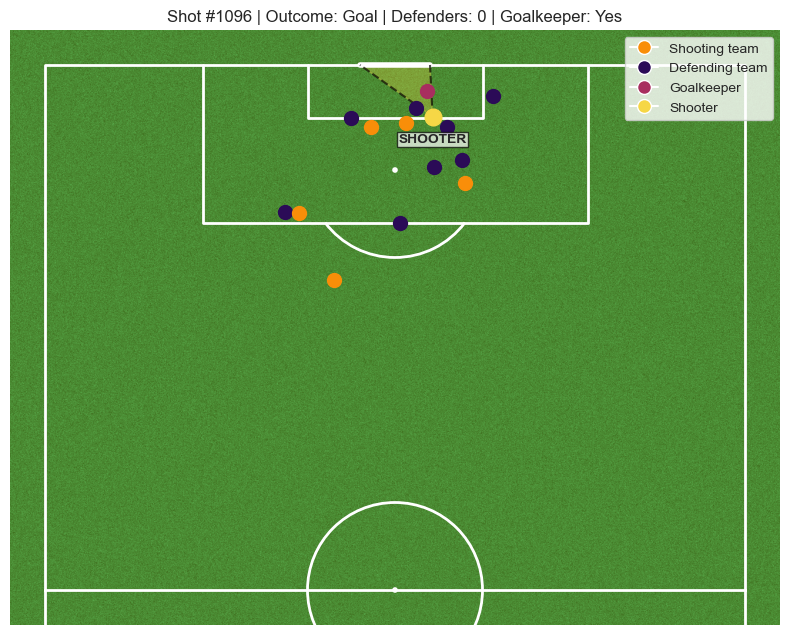

In [23]:
# Wizualizacja wybranego strzału
shot_index = 1096
fig, ax = visualize_shot_situation(df_shots, shot_index)

## Data Exploration

### Analysis of Binary Variables Relative to Target Variable

To better understand the data, I examined how shot effectiveness differs depending on the values of binary variables (0/1). For this purpose, I created column charts for the variables: **under_pressure**, **shot_first_time**, **normal_shot**, **open_play_shot**, **goalkeeper_in_path**. The left column illustrates the percentage effectiveness for observations that take value 0 for a given variable, while the right column shows effectiveness for shots labeled 1 for the given variable.

Binary features comparison saved to ../assets/eda/binary_features_comparison.png


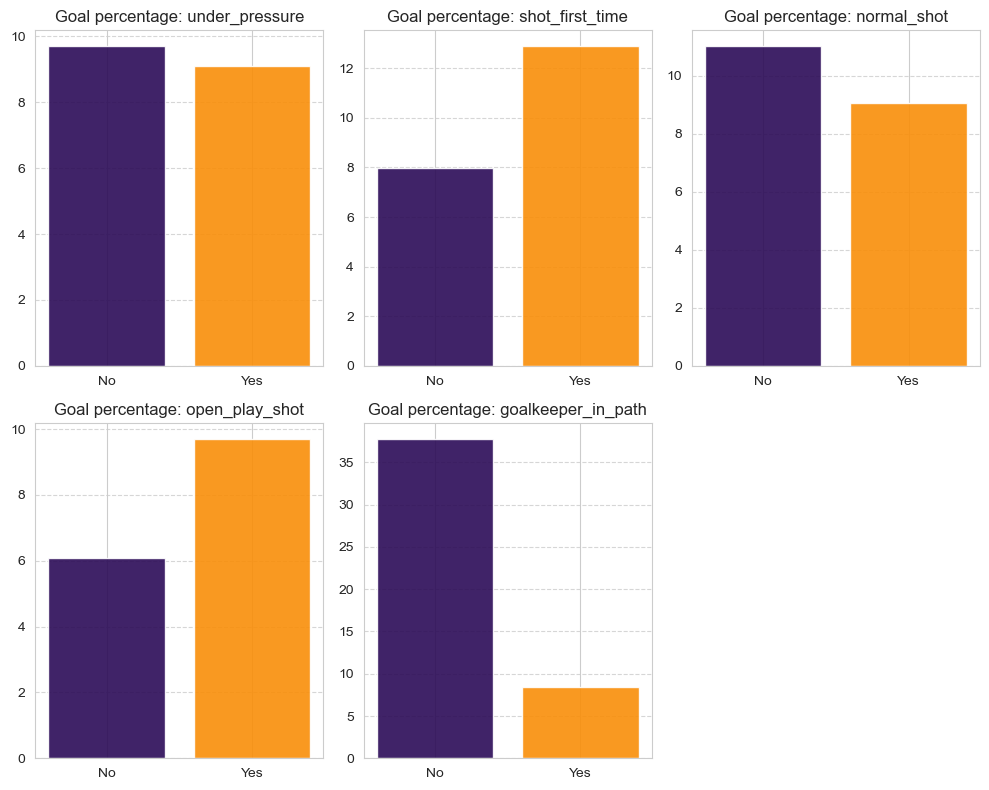

In [24]:
bin_features = ['under_pressure', 'shot_first_time', 'normal_shot', 'open_play_shot', 'goalkeeper_in_path']
fig, ax = plot_binary_features_comparison(df_shots, features=bin_features, save_path='../assets/eda/binary_features_comparison.png')

##### Under_pressure
- Shots without pressure have slightly higher effectiveness (**9.8%**) than shots under pressure (**9.0%**)
- The difference is relatively small, suggesting that opponent pressure has a moderate impact on effectiveness

##### Shot_first_time
- First-time shots have significantly higher effectiveness (**13.0%**) than shots preceded by ball control (**7.8%**)
- This may result from the element of surprise for the goalkeeper or the fact that first-time shots are usually taken in better situations

##### Normal_shot
- Normal shots (Yes) have an effectiveness of **9.5%**, marginally higher than special techniques (No) at **9.0%**
- The difference is practically negligible — special techniques (primarily half volleys and volleys, ~22% of shots combined) are more technically demanding but are often taken closer to goal, which partially compensates for the added difficulty
- The variable may carry limited standalone predictive signal, but could prove useful in combination with distance

##### Open_play_shot
- Shots from open play have higher effectiveness (**9.7%**) than direct free kick shots (**6.2%**)
- This result may be surprising, as set pieces are often considered good scoring opportunities, but both defenders and the goalkeeper are better prepared for the shot in these structured situations

##### Goalkeeper_in_path
- The clearest difference of all: shots without a goalkeeper on the shot line have effectiveness of **~35%**, while shots with a goalkeeper in the path only **~7%**
- This confirms the crucial role of the goalkeeper — his presence on the shot line reduces the chance of scoring by more than four times

This analysis shows that the most decisive variable for the xG model is the presence of the goalkeeper on the shot line. Other variables, such as first-time shots and shot type, also carry a noticeable impact on the probability of scoring a goal.

### Shot Effectiveness Analysis by Body Part *(refined_body_part)*

The next variable I decided to examine was **refined_body_part**. This variable contains three categories: *better_foot*, *worse_foot*, *head*. Intuition suggests that shots taken with the better foot should be significantly more effective than those taken with the weaker foot. Additionally, the dominant foot should rather guarantee more goals than headers, which are often taken from difficult situations, surrounded by many defenders.

Stacked bar chart for refined_body_part saved to ../assets/eda/body_part.png


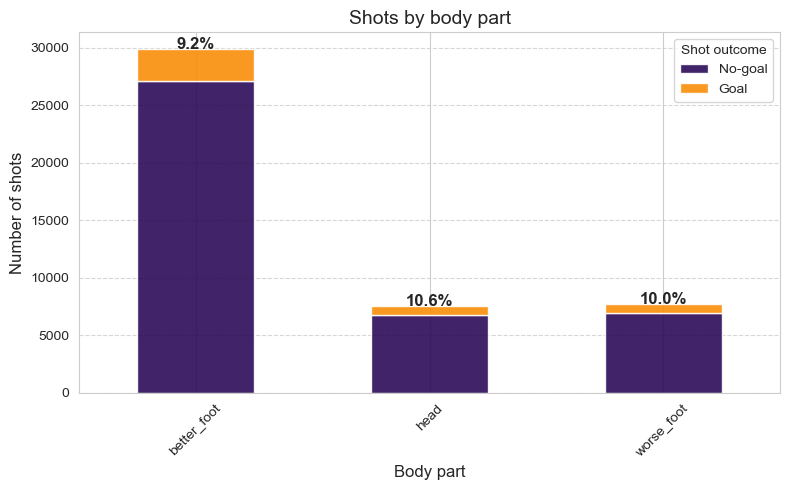

In [25]:
fig, ax = plot_stacked_bar(df_shots, 'refined_body_part', 'Shots by body part', 'Body part', save_path='../assets/eda/body_part.png')

Most shots are taken with the better foot, while the share of shots taken with the worse foot is comparable to headers — together they represent about half the volume generated by better foot shots. Interestingly, effectiveness across all three categories is similar: 10.6% for headers, 10.0% for the worse foot, and 9.2% for the better foot. Contrary to intuition, better foot shots are not the most effective. This may result from players being more inclined to take risks when shooting with their dominant foot, i.e., attempting shots from greater distances or unprepared positions. Additionally, players with one strongly dominant foot may be easier to "read" by defenders and goalkeepers (though there are exceptions like the legendary Arjen Robben and his famous cut to the left foot). To better understand this counterintuitive phenomenon, I created a stacked bar chart showing the share of shots taken with each body part depending on distance quantile.

Body part distribution by distance charts saved to ../assets/eda/body_part_by_distance_quantile.png


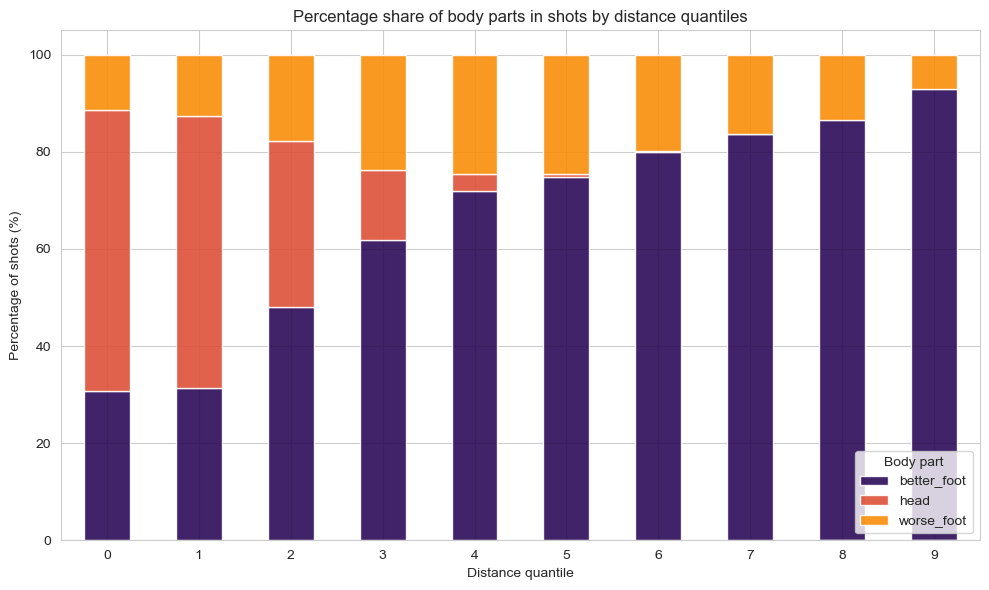

In [26]:
fig, ax = plot_body_part_by_distance_quantile(df_shots, save_path='../assets/eda/body_part_by_distance_quantile.png')

The chart confirms the thesis that better foot shots are usually taken from worse positions, at greater distances. After dividing shots into 10 equal quantiles, the share of better foot shots in the lowest quantiles (best positions) is only around 31%, while in the last four quantiles it exceeds 80%. The opposite pattern holds for headers — close to 57% in the first quantile, gradually declining to residual values by quantile 6. For worse foot shots, the share is small (~12-13%) in the early quantiles, driven by the dominance of headers. However, as the header share declines, worse foot shots increase through quantiles 4 and 5, before gradually yielding to better foot shots beyond that point. This observation signals that although overall effectiveness is not strongly differentiated across body parts, in combination with the distance variable it may positively influence the model's predictive power.

### Analysis of Ordinal Variable *(defenders_in_path)*

Another factor that seems extremely important for shot effectiveness appears to be the number of defenders in the shot path (**defenders_in_path**). As I noted in the earlier part of the analysis, the vast majority of shots are taken in situations where there is no defender on this potential shot path (49% of observations) or there is only one (34% of observations). It therefore seems that for the shooter it is very important to minimize the number of opponents on the stretch between him and the goal. If this is indeed beneficial, the data should confirm it.

Stacked bar chart for defenders_in_path saved to ../assets/eda/defenders_in_path.png


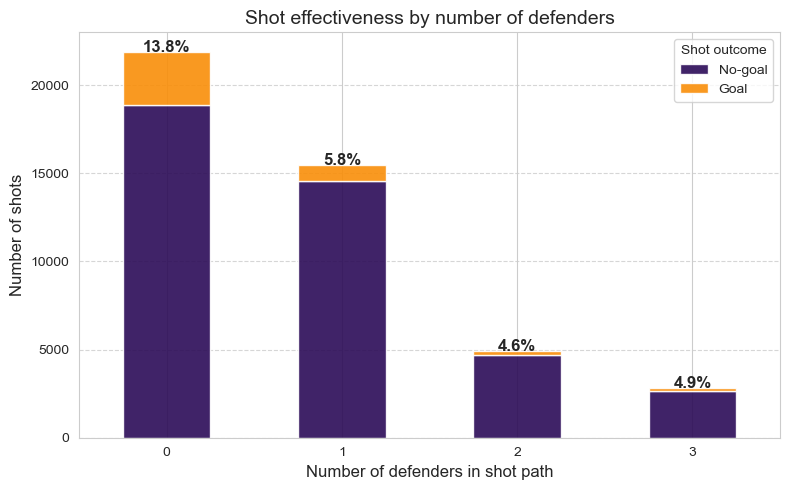

In [27]:
fig, ax = plot_stacked_bar(df_shots, 'defenders_in_path', 'Shot effectiveness by number of defenders', 'Number of defenders in shot path', save_path='../assets/eda/defenders_in_path.png')

Indeed, the data confirms the logic that guides shooters. Shots without defenders in the path (*category 0*) have decidedly the highest effectiveness — **13.8%** of these shots end in a goal. After the appearance of one defender, this effectiveness drops more than twofold to **5.8%**. Each subsequent defender on the shot line no longer affects goal scoring difficulty to such a great extent — for situations with at least two defenders, the effectiveness indicator remains at **4.6–4.9%**.

This analysis clearly shows that the number of defenders in the shot path is a very important factor when modeling xG. Particularly significant is the difference between shots without defenders and shots with even one defender in the path — an important signal for defending teams that even a single player can significantly hinder goal scoring. Meanwhile, the volume of shots without a defender and with one defender shows how important it is for shooters to find the optimal position at the right time to take a shot and maximize their chances of scoring a goal.

### Shot Effectiveness by Play Pattern *(play_pattern)*

The **play_pattern** variable describes the type of possession that led to the shot. I grouped the original categories into four: **corner**, **set_piece** (free kicks), **counter** (counter-attacks), and **open_play** (reference category). Understanding how effectiveness varies across these patterns helps assess whether the tactical context of a shot carries predictive value beyond pure geometry.

Stacked bar chart for play_pattern_group saved to ../assets/eda/play_pattern.png


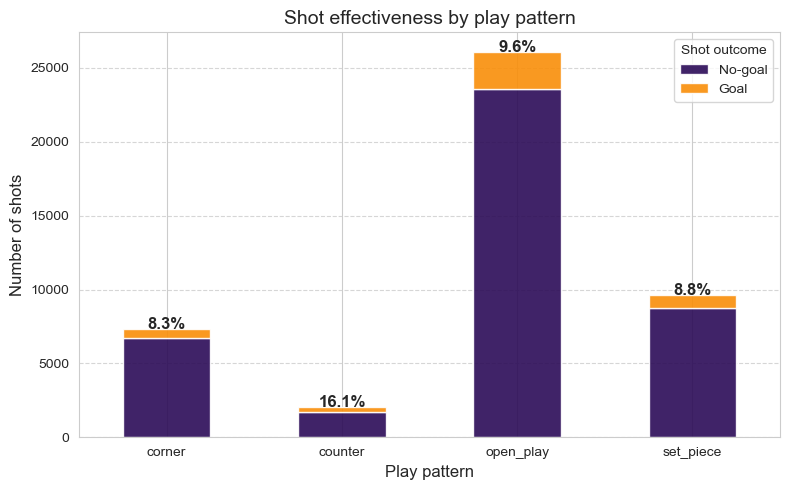

In [28]:
_pp_mapping = {
    'From Corner':    'corner',
    'From Free Kick': 'set_piece',
    'From Counter':   'counter',
}
df_shots['play_pattern_group'] = df_shots['play_pattern'].map(_pp_mapping).fillna('open_play')

fig, ax = plot_stacked_bar(df_shots, 'play_pattern_group',
                           'Shot effectiveness by play pattern', 'Play pattern',
                           save_path='../assets/eda/play_pattern.png')

df_shots = df_shots.drop(columns='play_pattern_group')

The chart reveals clear differences in shot effectiveness across play patterns. **Counter-attacks** stand out with a goal rate of **16.1%** — nearly double the dataset average — despite representing only 4.5% of all shots. This confirms that fast transitions catch defenses disorganized and create higher-quality chances.

**Open play** shots (57.8% of the dataset) show a goal rate of **9.6%**, serving as the baseline. **Set pieces** (free kicks, 21.3%) and **corners** (16.3%) both have lower effectiveness — **8.8%** and **8.3%** respectively — likely because defenders and the goalkeeper are well-positioned and prepared for the shot in these structured situations.

These differences justify including play pattern as a feature: the tactical context of how a chance was created carries meaningful predictive signal beyond shot geometry alone.

### Shot Effectiveness by Build-Up Length *(n_passes_in_sequence)*

The **n_passes_in_sequence** variable counts the number of passes in the possession leading up to the shot. This captures build-up complexity: direct attacks with few passes versus patient possession sequences. Individual values (0-9) are shown separately, with 10+ grouped together.

Passes in sequence chart saved to ../assets/eda/passes_in_sequence_effectiveness.png


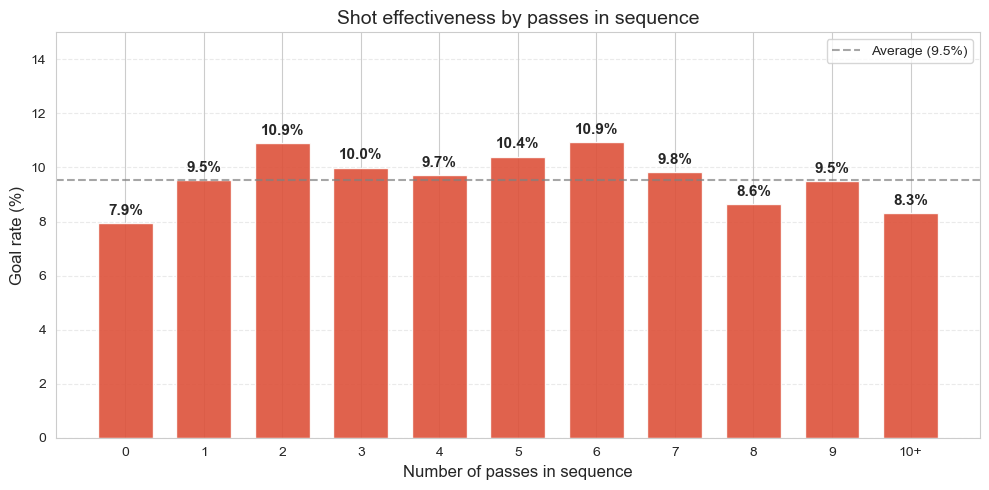

In [29]:
fig, ax = plot_passes_in_sequence_effectiveness(df_shots, save_path='../assets/eda/passes_in_sequence_effectiveness.png')

The chart reveals a nuanced relationship between build-up length and shot effectiveness.

Shots with **0 passes** have a relatively low goal rate of **7.9%**. This is largely explained by the composition of this group: 88% of these shots are **set pieces** (free kicks), where the goalkeeper and defenders are well-positioned — consistent with the **8.8%** set piece goal rate observed in the play pattern analysis above.

Effectiveness rises sharply after **1 pass** (9.5%) and peaks at **2 passes** (**10.9%**). These situations are characteristic of **high turnovers in the attacking third** — quick pressing or interceptions high up the pitch allow for an immediate threat on goal before the defense has time to reorganize. One or two passes are enough to find the shooter, but not enough for the defense to reset. The rate stays elevated through **5–6 passes** (10.4–10.9%), indicating that well-constructed medium-length build-ups also produce good opportunities.

Beyond **7 passes**, effectiveness gradually declines: 8 passes (**8.6%**), 9 passes (**9.5%**), 10+ (**8.3%**). Prolonged possession allows defenders to settle into shape and compress space, reducing the quality of the eventual shot.

The log transformation (log1p) applied to this variable is well-suited to this pattern: it compresses the high end where additional passes show diminishing marginal effect, while preserving the meaningful differences in the 0–6 range.

### Continuous variables: distance and angle 

A first continuous variable to examine is **goalkeeper_distance_ratio**.

Goalkeeper distance ratio distribution plot saved to ../assets/eda/goalkeeper_distance_ratio_distribution.png


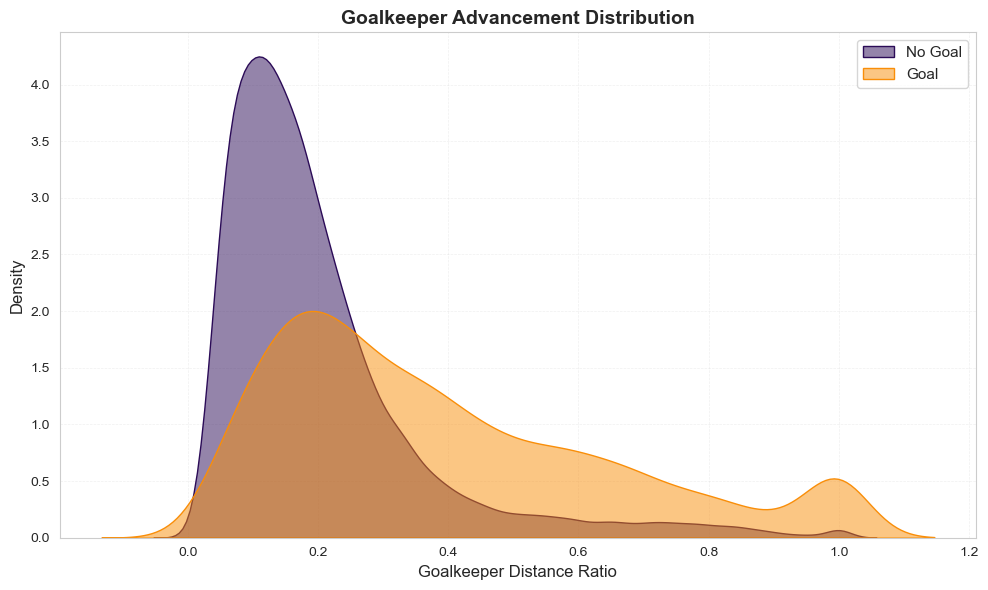

In [30]:
fig, ax = plot_goalkeeper_distance_ratio_distribution(df_shots, save_path='../assets/eda/goalkeeper_distance_ratio_distribution.png')

The visualization demonstrates a clear relationship between goalkeeper positioning and shot effectiveness. The distribution for non-goals (purple) is **heavily concentrated at lower ratio values**, peaking around **0.2**, indicating that goalkeepers typically stay closer to the goal line during unsuccessful shots. Conversely, the goal distribution (gold) is **shifted rightward with a broader spread** — showing substantial density even at high ratio values (0.6–1.0) and a characteristic **second peak at ~1.0**, corresponding to situations where the goalkeeper advanced very far off their line (e.g. one-on-one situations). This bimodal shape suggests two distinct categories of goal-scoring situations: standard shots against a moderately advanced goalkeeper, and extreme cases of aggressive positioning. This pattern reveals that goals are more likely when goalkeepers advance further from their goal line. The overlap between distributions occurs mainly in the **0.1–0.4** range, where outcomes depend on additional factors.

Next continuous variables, **distance** and **angle**, are based on the same raw variables, namely **x** and **y** extracted from the **location** variable. This raises concerns that they may be strongly dependent on each other. To better examine these variables, I created a heatmap showing how shot effectiveness changes depending on angle and distance quantiles, and I also determined the correlation matrix for these variables.

Shot effectiveness heatmap saved to ../assets/eda/shot_success_heatmap.png
             angle  distance
angle     1.000000 -0.757387
distance -0.757387  1.000000


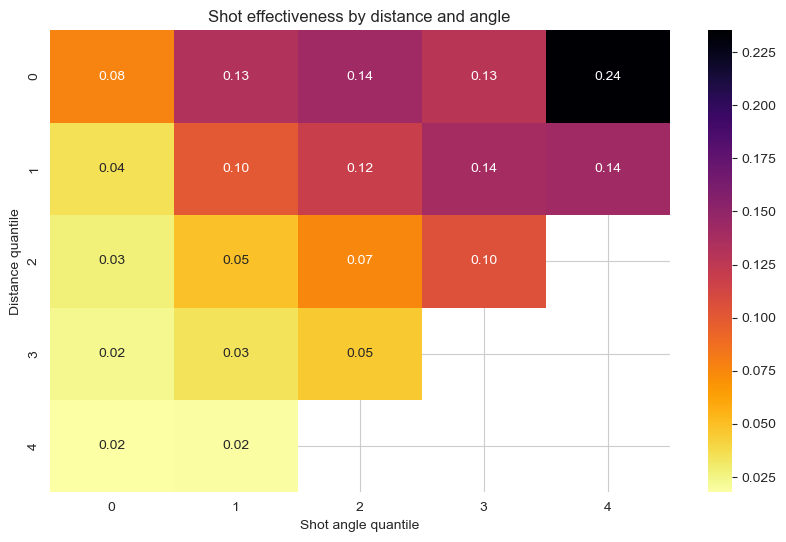

In [31]:
fig, ax = plot_shot_success_heatmap(df_shots, quantiles=5, show_corr=True, save_path='../assets/eda/shot_success_heatmap.png')

The concerns about strong dependence between both variables were justified — the correlation matrix indicates a strong negative correlation of **-0.76** (the greater the distance from goal, the smaller the shot angle).

After analyzing the heatmap, we can confirm that the highest shot effectiveness (**0.24**, i.e., **24%**) occurs at small distances and large shot angles, which aligns with football intuition. The effectiveness gradient is visible along both distance and angle axes, but values along rows (for constant distance) suggest that shot angle may be a better individual predictor of effectiveness. Effectiveness drastically drops at large distances, reaching only **2%** for the most distant shots. Also worth noting are the **empty cells** in the bottom-right corner of the heatmap — the combination of large distance and large angle is geometrically impossible, which visually confirms the strong correlation between both variables in its own right.

Variable collinearity poses a challenge for modeling. Despite the strong correlation, I decided to keep both variables in further analysis, planning to apply regularization techniques in the modeling process to control potential problems related to collinearity.

This analysis provides valuable information about geometric aspects affecting shot effectiveness and will form the basis for building an expected goals (xG) model. To confirm these considerations, I also prepared a column chart showing shot effectiveness depending on distance quantile and an analogous one divided into angle quantiles (this time I divided the data into 15 quantiles for better visualization).

Effectiveness by quantiles charts saved to ../assets/eda/shot_effectiveness_by_quantiles.png


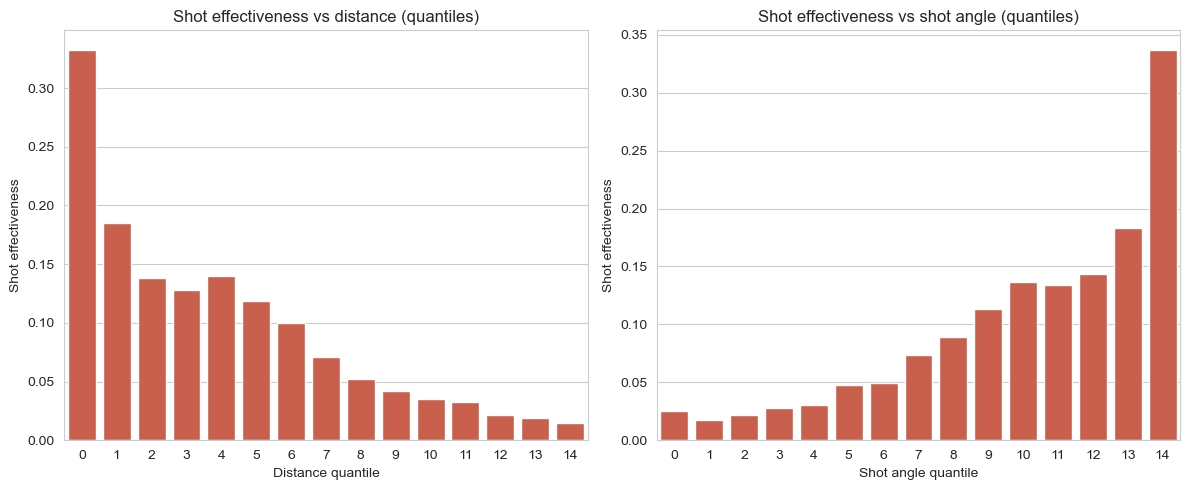

In [32]:
fig, ax = plot_shot_effectiveness_by_quantiles(df_shots, save_path='../assets/eda/shot_effectiveness_by_quantiles.png')

In [33]:
distance_skew = stats.skew(df_shots['distance'])
angle_skew = stats.skew(df_shots['angle'])

print("Variable skewness:")
print(f"Distance: {distance_skew:.3f}")
print(f"Shot angle: {angle_skew:.3f}")

Variable skewness:
Distance: 0.578
Shot angle: 2.183


In the case of distance, we clearly see that the greater the distance (higher quantile), the lower the shot effectiveness. The opposite situation applies to shot angle. The chance increases with each subsequent quantile - therefore along with the increase in shot angle. Additionally, I checked the skewness of both continuous variables, taking 1 as the threshold. As expected, the shot angle distribution is strongly skewed (2.18) and logarithmic transformation will be necessary for this variable.

Shot angle distribution histograms saved to ../assets/eda/angle_distribution.png
Skewness of original variables:
Shot angle: 2.183

Skewness of log-transformed variables:
Log(shot angle): 0.540


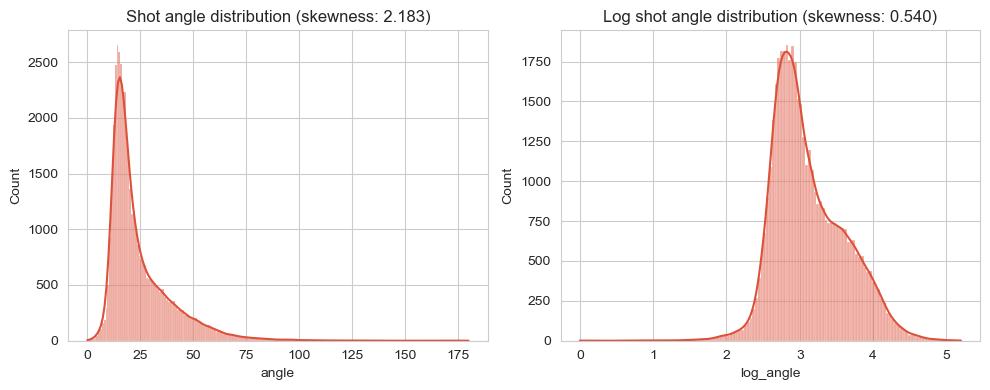

In [34]:
fig, ax = plot_angle_distribution(df_shots, save_path='../assets/eda/angle_distribution.png')

Analysis of the **angle** variable distribution revealed strong right-sided asymmetry (skewness = 2.183). Most observations were concentrated in the range of small angles (below 25 degrees), which corresponds to more difficult shooting situations, while large angles (corresponding to better positions) naturally occur much less frequently.

Application of logarithmic transformation significantly improved the variable distribution, reducing skewness to 0.540. The resulting distribution is much closer to normal, which will increase the effectiveness of statistical modeling. Thanks to this transformation, the impact of shot angle on the probability of scoring a goal will be better captured across the entire range of values, which should translate to improved quality of the expected goals model.

### Standardization and Dummy Encoding

After analyzing the variables, the next step was standardization of continuous variables. Three variables are standardized: **distance**, **log_angle**, and **log_passes_in_sequence**. This is primarily needed for Logistic Regression, which is sensitive to feature scales, while tree-based models (Random Forest, XGBoost) are invariant to monotone transformations. Additionally, I called descriptive statistics for these variables to assess whether the transformation proceeded correctly.

In [35]:
continuous_vars = ['distance', 'log_angle', 'log_passes_in_sequence']
df_shots = standardize_features(df_shots, continuous_vars)
df_shots[['distance_scaled', 'log_angle_scaled', 'log_passes_in_sequence_scaled']].describe()

,distance_scaled,log_angle_scaled,log_passes_in_sequence_scaled
count,4.510800e+04,4.510800e+04,4.510800e+04
mean,-1.625610e-16,-1.240000e-15,1.045935e-16
std,1.000011e+00,1.000011e+00,1.000011e+00
min,-2.174349e+00,-6.344615e+00,-2.021835e+00
25%,-8.203967e-01,-7.228099e-01,-6.730887e-01
50%,-5.600621e-02,-2.251189e-01,-4.595713e-02
75%,7.352403e-01,6.610891e-01,6.756581e-01
max,7.966568e+00,4.231395e+00,3.342458e+00


Standardization proceeded according to assumptions, i.e., the mean of standardized variables is close to 0, and the standard deviation equals 1. Small deviations from ideal values result from limited precision of floating-point calculations and are completely normal.

The next step in variable preparation was creating dummies for the categorical (non-binary) variable, i.e., **refined_body_part**. In this process, two new binary variables were created: **better_foot**, **worse_foot**. To avoid collinearity, I removed the **head** variable. Values of 0 for both variables indicating foot shots are equivalent to a header.

In [36]:
df_shots = create_dummies(df_shots, 'refined_body_part', drop_category='head')

In [37]:
df_shots = transform_play_pattern(df_shots)

print(df_shots[['corner', 'set_piece', 'counter']].sum())
print(f"\nopen_play shots: {(df_shots[['corner','set_piece','counter']].sum(axis=1) == 0).sum()}")

corner       7352
set_piece    9611
counter      2039
dtype: int64

open_play shots: 26106


In [38]:
df_shots.columns

Index(['shot_outcome', 'under_pressure', 'location', 'shot_technique',
       'shot_body_part', 'shot_type', 'shot_first_time', 'shot_open_goal',
       'shot_one_on_one', 'shot_follows_dribble', 'shot_freeze_frame',
       'player_id', 'n_passes_in_sequence', 'x', 'y', 'distance_to_end_line',
       'distance', 'angle', 'foot_type', 'normal_shot', 'open_play_shot',
       'defenders_in_path', 'goalkeeper_in_path', 'goalkeeper_distance_ratio',
       'log_passes_in_sequence', 'distance_quantile', 'angle_quantile',
       'log_angle', 'distance_scaled', 'log_angle_scaled',
       'log_passes_in_sequence_scaled', 'better_foot', 'worse_foot', 'corner',
       'counter', 'set_piece'],
      dtype='object')

### Removing Irrelevant Variables

After completing all transformations, I narrow the dataset to the final **15 model features**: distance_scaled, log_angle_scaled, log_passes_in_sequence_scaled, under_pressure, shot_first_time, better_foot, worse_foot, goalkeeper_in_path, open_play_shot, normal_shot, defenders_in_path, goalkeeper_distance_ratio, corner, set_piece, counter. All intermediate and raw columns (location, shot_technique, shot_freeze_frame, player_id, etc.) are dropped. The spatial coordinates (x, y) are saved separately for visualization purposes.

In [39]:
# Save spatial coordinates before narrowing df_shots to model features
df_spatial = df_shots[['x', 'y']].copy()

In [40]:
df_shots = df_shots[[
        'shot_outcome', 'under_pressure',
        'shot_first_time', 'distance_scaled', 'log_angle_scaled',
        'better_foot', 'worse_foot', 'goalkeeper_in_path', 'open_play_shot',
        'normal_shot', 'defenders_in_path', 'goalkeeper_distance_ratio',
        'log_passes_in_sequence_scaled',
        'corner', 'set_piece', 'counter']]

print(df_shots.shape)
print(df_shots.head())

(45108, 16)
   shot_outcome  under_pressure  shot_first_time  distance_scaled  \
0             1               1                0        -1.202813   
1             0               0                0         1.373219   
2             0               1                0        -1.123302   
3             0               0                1        -0.048027   
4             0               0                1         0.298258   

   log_angle_scaled  better_foot  worse_foot  goalkeeper_in_path  \
0          1.395579            0           0                   1   
1         -1.274038            1           0                   1   
2          1.413147            0           0                   1   
3         -1.086465            0           1                   1   
4         -0.771647            1           0                   1   

   open_play_shot  normal_shot  defenders_in_path  goalkeeper_distance_ratio  \
0               1            1                  0                   0.242477   
1   

## MODEL BUILDING

### SPLIT INTO SETS: TRAINING, CALIBRATION AND TEST

In the final dataset, **45,108 observations** remained with 1 target variable (**shot_outcome**) and **15 explanatory variables**.

The data was divided into three independent sets:

1. **Training set (80% of 2015/16 club data)** -- used for model training and hyperparameter tuning. Hyperopt (TPE algorithm) searches the hyperparameter space using **4-fold stratified cross-validation** as the objective: the mean CV ROC AUC across folds guides the search, and the model with best parameters is retrained on the full training set. **No resampling is applied** -- the natural goal rate (~10%) is preserved, as resampling would distort probability estimates and undermine the xG interpretation where calibrated probabilities are the primary output.

2. **Calibration set (20% of 2015/16 club data)** -- used to evaluate the best model and compare calibration methods. Maintaining the natural class distribution is essential here for reliable probability assessment.

3. **Test set (FIFA World Cup 2022)** -- a true out-of-sample holdout from a completely different competition and context (international tournament vs. club leagues, different era). Touched exactly once at the very end to report final performance. Using a different competition as test set provides a stronger generalization signal than a random split of the same dataset.

In [41]:
# --- Train / Calibration split (80/20 from 2015/16 club data) ---
X = df_shots.drop(['shot_outcome'], axis=1)
y = df_shots['shot_outcome']

X_train, X_calib, y_train, y_calib = prepare_train_calibration_split(X, y)

# --- Test set: FIFA World Cup 2022 ---
X_test, y_test, df_test_spatial = prepare_test_set(FIFA_2022_PATH, continuous_vars, X_train.columns)

Train size: 36086 | Calibration size: 9022
Goal proportion in training set: 0.10
Test set (FIFA 2022):  1417 shots | Goal rate: 0.11


### EVALUATION DEFINITION

#### Calibration

To assess probability calibration, three methods are compared on the **calibration set**:

- **Beta Calibration** -- parametric transformation in logit space with three parameters (a, b, c), optimized by minimizing log loss using Nelder-Mead. Flexible and well-suited for extreme probability values common in xG modeling.
- **Isotonic Regression** -- non-parametric monotone step function. Most flexible of the three but prone to overfitting on smaller datasets.
- **Platt Scaling** -- logistic regression fitted on raw model outputs. Simple, low-variance, effective when miscalibration follows a sigmoid pattern.

All three methods are both fitted and evaluated on the **same calibration set**. This introduces a small optimistic bias -- most notable for Isotonic Regression -- but is acceptable for two reasons: first, limited held-out data makes a further split impractical; second, the raw model predictions proved to be already well-calibrated, meaning calibration serves as a **verification step** rather than a critical correction. The best method is selected by manual inspection of Brier Score, ECE, xG/Goals ratio, and the reliability diagram.

#### Calibration Implementation
1. Raw model probabilities extracted on calibration set
2. Each method fitted on these raw probabilities
3. Calibrated probabilities evaluated against true outcomes on the same set
4. Visual inspection via reliability diagram and expected vs. actual goals chart
5. Best method applied to the final FIFA 2022 test evaluation

#### Evaluation Metrics

The following metrics are used throughout evaluation:

1. **ROC AUC** -- measures the model's ability to rank shots by goal probability regardless of calibration. A value of 0.5 equals random, 1.0 is perfect. Used for hyperparameter tuning (CV) and model selection.

2. **Brier Score** -- mean squared error between predicted probabilities and binary outcomes. Lower is better. With a ~10% goal rate, a naive model always predicting 0.10 scores ~0.090, so meaningful improvement requires beating this baseline.

3. **ECE (Expected Calibration Error)** -- quantile-based calibration error: weighted average of |mean predicted - mean actual| across equal-frequency bins. Captures whether shots with xG = 0.3 actually end in goals ~30% of the time.

4. **xG/Goals ratio** -- sum of predicted xG divided by actual number of goals. Ideal value is 1.0. Measures global agreement between predictions and observed outcomes -- the key metric for practical applications such as season-level performance assessment.

The evaluation is complemented by:
- **ROC Curve** -- visualizes the trade-off between true and false positive rates
- **Reliability Diagram** -- shows how well predicted probabilities match observed goal frequencies
- **Expected vs. Actual Goals chart** -- compares raw and calibrated xG totals against true goal count

### Model 1 - Logistic Regression

In [42]:
model_lr, metrics_lr = train_logistic_regression(X_train, y_train)

Optimizing Logistic Regression...
100%|███████████████████████████████████████████████| 30/30 [00:11<00:00,  2.53trial/s, best loss: -0.8064592752675571]
Best parameters: {'C': 0.7475552630456072, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
CV ROC AUC: 0.8065 ± 0.0043


#### Model Parameters

The best Logistic Regression hyperparameters were found by Hyperopt TPE with 4-fold CV:
- **penalty**: l2
- **solver**: lbfgs
- **C**: 0.748
- **max_iter**: 500


**CV ROC AUC**: 0.8065 ± 0.0043

### Model 2 - Random Forest

In [43]:
model_rf, metrics_rf = train_random_forest(X_train, y_train)

Optimizing Random Forest...
100%|███████████████████████████████████████████████| 30/30 [04:56<00:00,  9.89s/trial, best loss: -0.8093551903613183]
Best parameters: {'n_estimators': 500, 'max_depth': 10, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': 'sqrt'}
CV ROC AUC: 0.8094 ± 0.0054


#### Model Parameters

The best Random Forest hyperparameters were found by Hyperopt TPE with 4-fold CV:
- **n_estimators**: 500
- **max_depth**: 10
- **min_samples_split**: 11
- **min_samples_leaf**: 5
- **max_features**: sqrt

**CV ROC AUC**: 0.8094 ± 0.0054

### Model 3 - XGBoost

In [44]:
model_xgb, metrics_xgb = train_xgboost(X_train, y_train)

Optimizing XGBoost...
100%|███████████████████████████████████████████████| 30/30 [03:34<00:00,  7.15s/trial, best loss: -0.8134793700869836]
Best parameters: {'n_estimators': 750, 'max_depth': 3, 'learning_rate': 0.019611378263551436, 'subsample': 0.840575790983322, 'colsample_bytree': 0.8698116740526126}
CV ROC AUC: 0.8135 ± 0.0038


#### Model Parameters

The best XGBoost hyperparameters were found by Hyperopt TPE with 4-fold CV:
- **n_estimators**: 750
- **max_depth**: 3
- **learning_rate**: 0.0196
- **subsample**: 0.840
- **colsample_bytree**: 0.870

**CV ROC AUC**: 0.8135 ± 0.0038

In [45]:
# --- Model comparison by CV ROC AUC ---
comparison = pd.DataFrame([metrics_lr, metrics_rf, metrics_xgb],
                          index=['Logistic Regression', 'Random Forest', 'XGBoost'])
print(comparison.to_string())

# --- Pick best model by CV ROC AUC ---
best_model_name = comparison['CV ROC AUC'].idxmax()
best_model = {'Logistic Regression': model_lr, 'Random Forest': model_rf, 'XGBoost': model_xgb}[best_model_name]
print(f"Best model: {best_model_name} (CV ROC AUC = {comparison.loc[best_model_name, 'CV ROC AUC']:.4f})")

                     CV ROC AUC  CV ROC AUC std
Logistic Regression      0.8065          0.0043
Random Forest            0.8094          0.0054
XGBoost                  0.8135          0.0038
Best model: XGBoost (CV ROC AUC = 0.8135)


**XGBoost** was selected as the final model based on the highest CV ROC AUC (**0.8134**). It is worth noting, however, that the differences between models are small — XGBoost's advantage over Random Forest is only 0.004, and over Logistic Regression 0.007. This suggests that feature engineering quality matters more than the choice of algorithm itself.

In [46]:
# --- Raw evaluation on calibration set ---

print("--- Raw model evaluation on calibration set ---")

calib_eval_metrics = evaluate_model(best_model, X_calib, y_calib, save_plots=True, model_name='xgboost')

--- Raw model evaluation on calibration set ---
  ROC AUC:      0.8201
  Brier Score:  0.0708
  ECE:          0.0088
  xG/Goals:     0.9812
ROC curve saved to ../assets/models/xgboost/roc_curve.png


In [47]:
# --- Calibration comparison on calibration set ---

print("--- Calibration comparison on calibration set ---")

calibrators, calib_metrics = calibrate_best_model(best_model, X_calib, y_calib, save_plots=True, model_name='xgboost')

--- Calibration comparison on calibration set ---

Calibration comparison on calib set
                Raw    Beta  Isotonic   Platt
Metric                                       
Brier Score  0.0708  0.0708    0.0699  0.0720
ECE          0.0088  0.0090    0.0000  0.0266
xG/Goals     0.9812  1.0000    1.0000  1.0000


In [48]:
best_name = 'Raw'  # options: 'Raw', 'Beta', 'Isotonic', 'Platt'

**Raw** probabilities were selected as the final method — no post-hoc correction applied. Although Isotonic achieves a marginally better Brier Score (0.0701 vs 0.0708) and a perfect ECE = 0.0000, the latter is symptomatic of **overfitting** — isotonic regression is a non-parametric step function that, when both fitted and evaluated on the same calibration set, can conform too closely to the data without generalizing to new observations. Raw with ECE = **0.0075** is already very well calibrated without any correction — a direct consequence of training without resampling, which preserves the natural class distribution (~10% goals) and allows the model to learn realistic probability estimates directly.

In [49]:
print("--- Final evaluation on FIFA World Cup 2022 ---")

final_metrics = evaluate_model(best_model, X_test, y_test, calibrator=calibrators[best_name], save_plots=True, model_name='xgboost')

--- Final evaluation on FIFA World Cup 2022 ---
  ROC AUC:      0.8052
  Brier Score:  0.0766
  ECE:          0.0173
  xG/Goals:     0.9154
ROC curve saved to ../assets/models/xgboost/roc_curve.png


The FIFA World Cup 2022 test set provides a strong generalization test: the model was trained exclusively on 2015/16 club data and evaluated on an international tournament from 2022 — a different competition, playing style, and era. The ROC AUC of **0.8052** is nearly identical to the calibration set result (**0.8201**), confirming that the model learned genuine shot quality signals rather than league-specific patterns. The Brier Score of **0.0766** remains close to the calibration value (0.0708), and ECE of **0.0173** indicates good probability calibration out-of-sample as well. The xG/Goals ratio of **0.9154** reflects a slight underestimation of total xG relative to actual goals — acceptable given the stylistic differences between club football and an international tournament.

### SHAP Feature Importance Analysis

SHAP (SHapley Additive exPlanations) values are computed using `TreeExplainer` with `model_output='probability'` and interventional feature perturbation (background: 100 random training observations). This means each SHAP value represents a **direct contribution to goal probability** -- e.g., a value of +0.03 means that feature increased the predicted xG by 3 percentage points for that shot. This is more interpretable than the default log-odds space and aligns naturally with the xG framing where probabilities are the primary output of interest.

 99%|===================| 1403/1417 [00:25<00:00]        

SHAP plot saved to ../assets/models/xgboost/shap_summary.png


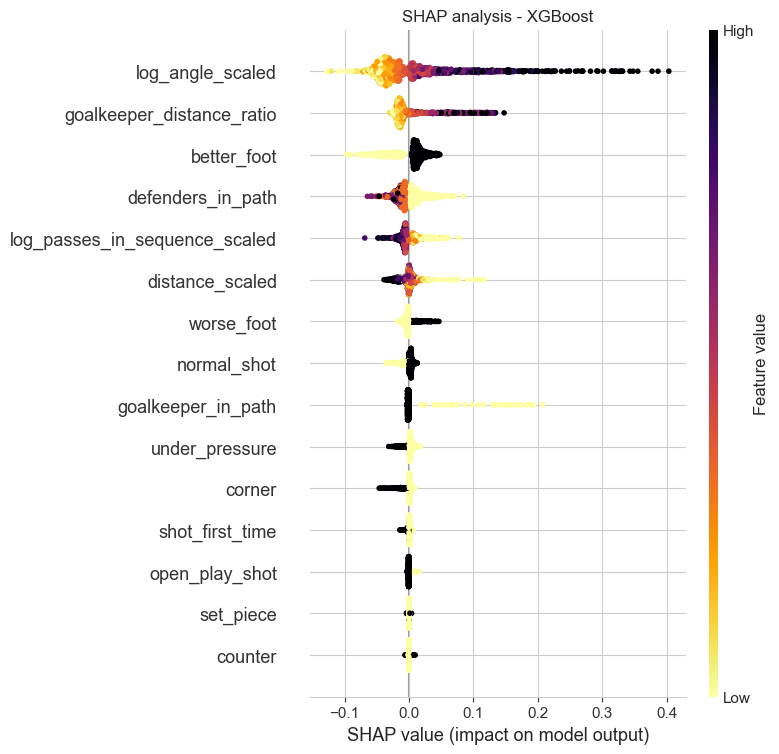

In [50]:
X_background = X_train.sample(100, random_state=42)
plot_xg_shap_summary(model_xgb, X_test, model_name="XGBoost", X_background=X_background, save_path='../assets/models/xgboost/shap_summary.png')

**Global Feature Impact**

The SHAP summary plot shows each feature's contribution to goal probability (x-axis in probability units), ranked from most to least impactful.

**Top 3 features:**
- **log_angle_scaled** -- the most dominant feature. High angle values strongly increase goal probability, confirming that shot geometry is the primary determinant of xG. A wider shooting angle gives the striker more of the goal to aim at, with SHAP values reaching **+0.4** for the best positions.
- **better_foot** -- the second most important feature. Shots with the dominant foot increase xG, which is intuitive. Interestingly, even high values of this feature generate moderate SHAP values, suggesting that the dominant foot alone -- without a good position -- does not guarantee high xG.
- **goalkeeper_distance_ratio** -- the third most important feature. High values (goalkeeper advanced far from the goal line) increase goal probability: an advanced keeper leaves more of the net exposed to a well-placed shot.

**Contextual and Technical Factors:**
- **defenders_in_path** -- a higher number of defenders between the shooter and goal clearly reduces xG, creating physical obstacles for the shot trajectory.
- **log_passes_in_sequence_scaled** -- the presence of this feature in 5th place confirms that the build-up context of an attacking move carries a meaningful predictive signal.
- **distance_scaled** -- low distance values significantly increase goal probability; shots from far out are heavily penalized.
- **worse_foot / normal_shot / goalkeeper_in_path** -- moderate impact, clustered close to zero.
- **shot_first_time, corner, set_piece, counter, open_play_shot** -- near-zero individual impact in SHAP space, though these variables may contribute signal through interactions with other features.

**Key Takeaway**

The SHAP analysis confirms that shot geometry (angle, distance) provides the baseline for xG, while the defensive context -- goalkeeper positioning and defenders in the shot path -- are the primary modifiers that give this model an advantage over basic geometry-only xG versions. The probability-space SHAP axis makes these contributions directly readable: the dominant features shift goal probability by several percentage points per shot.

xG scatter plot saved to ../assets/models/xgboost/xg_scatter.png


(<Figure size 800x800 with 2 Axes>, <Axes: >)

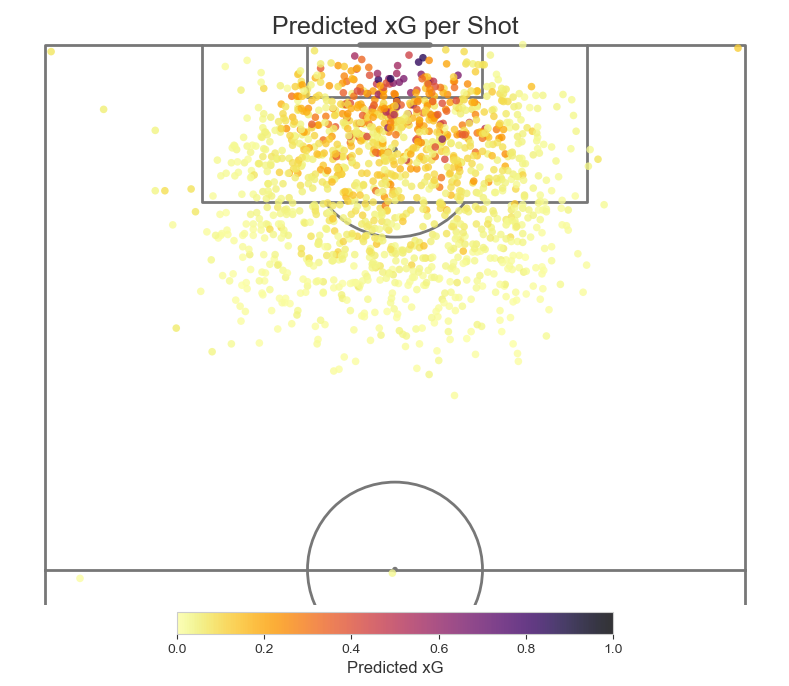

In [51]:
xg_preds = model_xgb.predict_proba(X_test)[:, 1]

x_coords = df_test_spatial['x'].values
y_coords = df_test_spatial['y'].values

plot_xg_scatter(x_coords, y_coords, xg_preds, save_path='../assets/models/xgboost/xg_scatter.png')

The shot map from the test set (FIFA World Cup 2022) visualizes the predicted xG value for each shot. The color of each point corresponds to its xG value — from yellow (low xG, difficult positions) through orange and red to black (high xG, excellent positions). The pattern is consistent with football intuition: the highest xG values cluster centrally near the goal and inside the six-yard box, while shots from greater distances and wide positions are consistently assigned low values. A few isolated high-xG points are also visible outside the penalty area — corresponding to situations with an exceptionally advanced goalkeeper or a minimal number of defenders on the shot line.

## Project Summary and Conclusions

### Model Comparison and Selection

| Model | CV ROC AUC | CV ROC AUC std |
|---|---|---|
| Logistic Regression | 0.8065 | 0.0043 |
| Random Forest | 0.8094 | 0.0054 |
| XGBoost | 0.8135 | 0.0038 |

**XGBoost** was selected as the final model based on the highest CV ROC AUC (**0.8135**). Model comparison was performed on training data via 4-fold stratified CV — the calibration and test sets were not involved in model selection. It is worth noting that the differences between algorithms are small, confirming that feature engineering quality matters more than the choice of algorithm itself.

### Calibration Assessment

| Method | Brier Score | ECE | xG/Goals |
|---|---|---|---|
| Raw | 0.0708 | 0.0088 | 0.9812 |
| Beta | 0.0708 | 0.0090 | 1.0000 |
| Isotonic | 0.0699 | 0.0000 | 1.0000 |
| Platt | 0.0720 | 0.0266 | 1.0000 |

The raw XGBoost probabilities proved to be **well-calibrated without correction** — a direct consequence of training without resampling, which preserves the natural class distribution and allows the model to learn realistic probability estimates directly. Although Isotonic achieves ECE = 0.0000, this is symptomatic of overfitting on the small calibration set. Raw with ECE = **0.0088** is already very well calibrated without any correction. Calibration acts as a verification step rather than a critical correction.

### Final Evaluation — FIFA World Cup 2022

| Metric | Value |
|---|---|
| ROC AUC | 0.8052 |
| Brier Score | 0.0766 |
| ECE | 0.0173 |
| xG/Goals | 0.9154 |

The FIFA World Cup 2022 test set provides a strong generalization test: the model was trained exclusively on 2015/16 club data and evaluated on an international tournament from 2022 — a different competition, playing style, and era. The ROC AUC of **0.8052** is nearly identical to the calibration set result (**0.8201**), the Brier Score of **0.0766** remains close to the calibration value (0.0708), and ECE of **0.0173** indicates good probability calibration out-of-sample as well. The xG/Goals ratio of **0.9154** reflects a slight underestimation of total xG relative to actual goals — acceptable given the stylistic differences between club football and an international tournament.

### Project Strengths

1. **Rigorous evaluation design**
   - Hyperparameter tuning via 4-fold CV on training data only — no leakage into calibration or test sets
   - FIFA World Cup 2022 as true out-of-sample test: different competition, different era
   - Test set touched exactly once, at the end

2. **Comprehensive feature engineering**
   - Geometric shot analysis (angle, distance from goal)
   - Freeze-frame exploitation: defenders in shot path, goalkeeper distance ratio
   - Body part contextualization (better_foot / worse_foot / head)
   - Sequence context: passes leading up to the shot, play pattern, first-time shots

3. **No resampling**
   - Natural ~10% goal rate preserved throughout training
   - Avoids probability distortion caused by undersampling or oversampling
   - Enables well-calibrated raw predictions without heavy post-hoc correction

4. **Interpretable SHAP analysis**
   - SHAP values computed in probability space (not log-odds)
   - Each value directly readable as a contribution to goal probability
   - Confirms that geometry and defensive context are the primary xG drivers

### Weaknesses and Limitations

1. **Limited calibration data**
   - Calibration methods fitted and evaluated on the same 20% set — introduces a small optimistic bias, particularly for Isotonic Regression
   - A larger dataset would allow a proper fit/eval split for calibration

2. **Training data scope**
   - Limited to one season (2015/16) and five European leagues
   - Does not capture evolution of playing styles or tactical trends over time

3. **Missing dynamic information**
   - No ball velocity, shot trajectory, or body position data
   - No information about preceding action quality (e.g. cross type, pass difficulty)

4. **Geometric collinearity**
   - Angle and distance are strongly correlated (r = **-0.76**)
   - Log transformation mitigates but does not eliminate this

### Key Conclusions

1. **Feature quality dominates model choice** — the performance gap between LR, RF, and XGBoost is small. The freeze-frame features (goalkeeper distance, defenders in path) provide the most differentiation over geometry-only xG.

2. **No resampling produces better-calibrated models** — without undersampling, raw model probabilities are already close to actual goal rates. Calibration confirms rather than corrects.

3. **Shot geometry is fundamental** — log_angle_scaled is the single most important feature, confirming that physical constraints on scoring (angle, distance) drive xG more than contextual factors.

4. **FIFA 2022 generalization** — evaluating on an entirely different competition tests whether the model captures genuine shot quality signals rather than league-specific patterns.

5. **Domain context is critical for feature interpretation** — the project demonstrates how raw statistics can be misleading without football domain knowledge. The clearest example is *refined_body_part*: at first glance, the low goal rate for better foot shots (9.2%) compared to headers (10.6%) and worse foot shots (10.0%) appears counterintuitive. Only by examining the share of each body part across distance quantiles does the mechanism become clear — players far more frequently attempt better foot shots from difficult, distant positions, while headers and worse foot shots cluster closer to goal. Without this additional layer of analysis, one might incorrectly discard the variable or — worse — draw the opposite conclusion from it.